In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('benchmark/merged_csv_final.csv')

# Classify circuit type from circuit name
def classify(name):
    if 'gausssum' in name: return 'Gaussian Sum'
    if 'treesum' in name: return 'Tree Sum'
    if 'seqsum' in name: return 'Sequential Sum'
    if 'bitonic' in name: return 'Bitonic Sort'
    if 'select' in name: return 'Selection'
    if 'treemech' in name: return 'Tree Mechanism'
    if 'distincthist' in name: return 'Distinct Elements (Histogram)'
    if 'distinct' in name: return 'Distinct Elements'
    if 'lcb' in name: return 'Linear Contextual Bandits'
    return 'Other'

df['circuit_type'] = df['circuit'].apply(classify)

print(f'Loaded {len(df)} rows')
print(f'Experiments: {sorted(df["experiment"].unique())}')
print(f'Circuits: {sorted(df["circuit_type"].unique())}')
print(f'N values: {sorted(df["n_clients"].unique())}')
print(f'Balanced values: {sorted(df["balanced"].unique())}')
df.head()

Loaded 32640 rows
Experiments: ['net_distinct_N1024_min_max_in', 'net_distinct_N1024_nonxor_bal', 'net_distinct_N1024_topo_bal', 'net_distinct_N1024_unbal', 'net_distinct_N128_min_max_in', 'net_distinct_N128_nonxor_bal', 'net_distinct_N128_topo_bal', 'net_distinct_N128_unbal', 'net_distinct_N16_min_max_in', 'net_distinct_N16_nonxor_bal', 'net_distinct_N16_topo_bal', 'net_distinct_N16_unbal', 'net_distinct_N256_min_max_in', 'net_distinct_N256_nonxor_bal', 'net_distinct_N256_topo_bal', 'net_distinct_N256_unbal', 'net_distinct_N32_min_max_in', 'net_distinct_N32_nonxor_bal', 'net_distinct_N32_topo_bal', 'net_distinct_N32_unbal', 'net_distinct_N512_min_max_in', 'net_distinct_N512_nonxor_bal', 'net_distinct_N512_topo_bal', 'net_distinct_N512_unbal', 'net_distinct_N64_min_max_in', 'net_distinct_N64_nonxor_bal', 'net_distinct_N64_topo_bal', 'net_distinct_N64_unbal', 'net_distinct_N8_min_max_in', 'net_distinct_N8_nonxor_bal', 'net_distinct_N8_topo_bal', 'net_distinct_N8_unbal', 'net_gausssum_N1

,experiment,n_clients,circuit,circuit_gates,bit_width,balanced,partition_mode,total_boundary_pins,client_id,num_gates,...,total_time_us,garbled_table_bytes,ot_are_bytes,boundary_bytes,total_bytes,wire_garble_bytes,wire_ot_are_bytes,wire_boundary_bytes,wire_total_bytes,circuit_type
0,net_distinct_N8_min_max_in,8,distinct,1923,8,1,min_max_in,418,0,244,...,107987.0,2688,276480,0,279168,2692,277096,1891,281683,Distinct Elements
1,net_distinct_N8_min_max_in,8,distinct,1923,8,1,min_max_in,418,1,207,...,941953.0,2208,276480,1290240,1568928,2212,277096,3412,282724,Distinct Elements
2,net_distinct_N8_min_max_in,8,distinct,1923,8,1,min_max_in,418,2,267,...,697603.0,2848,276480,2027520,2306848,2852,277096,5114,285066,Distinct Elements
3,net_distinct_N8_min_max_in,8,distinct,1923,8,1,min_max_in,418,3,216,...,613691.0,2304,276480,1720320,1999104,2308,277096,3634,283042,Distinct Elements
4,net_distinct_N8_min_max_in,8,distinct,1923,8,1,min_max_in,418,4,207,...,565102.0,2208,276480,1781760,2060448,2212,277096,4004,283316,Distinct Elements


In [2]:
# Aggregate per experiment, keyed by partition_mode (unbal / topo_bal / nonxor_bal / min_cut / min_max_in)
def compute_costs(group):
    n = group['n_clients'].iloc[0]
    circuit = group['circuit'].iloc[0]
    balanced = group['balanced'].iloc[0]
    gates = group['circuit_gates'].iloc[0]
    ct = group['circuit_type'].iloc[0]
    mode = group['partition_mode'].iloc[0]

    total_and = group['num_and'].sum()
    total_inputs = group['num_inputs'].sum()
    total_boundary = group['num_boundary_in'].sum()

    avg_comp_ms = group['total_time_us'].mean() / 1000.0
    max_comp_ms = group['total_time_us'].max() / 1000.0
    avg_comm_KB = group['total_bytes'].mean() / 1024.0
    max_comm_KB = group['total_bytes'].max() / 1024.0

    return pd.Series({
        'n_clients': n, 'circuit': circuit, 'circuit_gates': gates,
        'balanced': balanced, 'circuit_type': ct, 'mode': mode,
        'total_and': total_and, 'total_inputs': total_inputs,
        'total_boundary': total_boundary,
        'avg_comp_ms': avg_comp_ms, 'max_comp_ms': max_comp_ms,
        'avg_comm_KB': avg_comm_KB, 'max_comm_KB': max_comm_KB,
    })

runs = df.groupby('experiment').apply(compute_costs).reset_index()

# Unbalanced baseline (per circuit, per N)
unbal_base = (runs[runs['mode'] == 'unbal']
              .drop_duplicates(subset=['circuit', 'n_clients'], keep='first')
              .set_index(['circuit', 'n_clients'])[['max_comp_ms', 'max_comm_KB', 'avg_comp_ms', 'avg_comm_KB']])
unbal_base.columns = ['unbal_comp_ms', 'unbal_comm_KB', 'unbal_avg_comp_ms', 'unbal_avg_comm_KB']

# All balanced partition modes (only those actually present in the CSV are plotted).
BAL_MODES = ['topo_bal', 'nonxor_bal', 'min_cut', 'min_max_in']
present_modes = set(runs['mode'].unique())
BAL_MODES = [m for m in BAL_MODES if m in present_modes]
bal_runs = runs[runs['mode'].isin(BAL_MODES)].copy()
bal_runs = bal_runs.drop_duplicates(subset=['circuit', 'n_clients', 'mode'], keep='first')
bal_runs = bal_runs.join(unbal_base, on=['circuit', 'n_clients'])
bal_runs['comp_speedup'] = bal_runs['unbal_comp_ms'] / bal_runs['avg_comp_ms']
bal_runs['comm_speedup'] = bal_runs['unbal_comm_KB'] / bal_runs['avg_comm_KB']

# Plots start at N=N_MIN_PLOT. df keeps every row (used for raw breakdowns); bal_runs is what feeds the line plots, so we drop small-N rows here.
N_MIN_PLOT = 32
bal_runs = bal_runs[bal_runs['n_clients'] >= N_MIN_PLOT].copy()

print(f'Partition modes present: {sorted(runs["mode"].unique())}')
for ct in sorted(bal_runs['circuit_type'].unique()):
    print(f'\n--- {ct} ---')
    for m in BAL_MODES:
        sub = bal_runs[(bal_runs['circuit_type'] == ct) & (bal_runs['mode'] == m)].sort_values('n_clients')
        if len(sub) == 0:
            continue
        print(f'  [{m}]')
        for _, row in sub.iterrows():
            print(f"    N={int(row['n_clients']):3d}  avg={row['avg_comp_ms']:.1f}ms  "
                  f"max={row['max_comp_ms']:.1f}ms  unbal={row['unbal_comp_ms']:.1f}ms")


Partition modes present: ['min_max_in', 'nonxor_bal', 'topo_bal', 'unbal']

--- Distinct Elements ---
  [topo_bal]
    N= 32  avg=468.1ms  max=530.5ms  unbal=424.3ms
    N= 64  avg=516.8ms  max=605.1ms  unbal=1170.4ms
    N=128  avg=590.3ms  max=720.2ms  unbal=8302.2ms
    N=256  avg=711.7ms  max=869.2ms  unbal=22089.5ms
    N=512  avg=774.9ms  max=1275.7ms  unbal=42180.2ms
    N=1024  avg=861.1ms  max=1951.4ms  unbal=101064.0ms
  [nonxor_bal]
    N= 32  avg=453.7ms  max=589.7ms  unbal=424.3ms
    N= 64  avg=496.7ms  max=722.0ms  unbal=1170.4ms
    N=128  avg=579.9ms  max=860.2ms  unbal=8302.2ms
    N=256  avg=714.5ms  max=1005.3ms  unbal=22089.5ms
    N=512  avg=779.7ms  max=1147.6ms  unbal=42180.2ms
    N=1024  avg=862.6ms  max=1968.7ms  unbal=101064.0ms
  [min_max_in]
    N= 32  avg=452.7ms  max=521.5ms  unbal=424.3ms
    N= 64  avg=495.9ms  max=584.2ms  unbal=1170.4ms
    N=128  avg=573.5ms  max=717.9ms  unbal=8302.2ms
    N=256  avg=710.4ms  max=869.5ms  unbal=22089.5ms
    N=512 

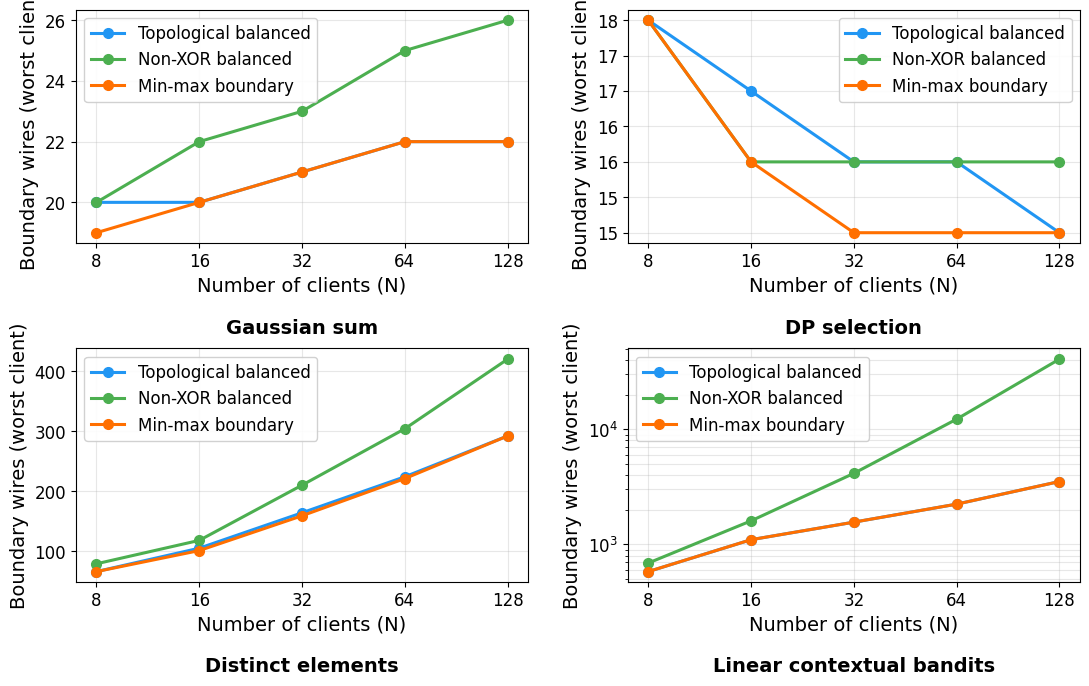

In [3]:
# ── Strategy comparison (N 128): worst-client boundary wires ──────────
from matplotlib.ticker import FuncFormatter, LogFormatterMathtext

DEMO_N = [8, 16, 32, 64, 128]
DEMO_MODES = ['topo_bal', 'nonxor_bal', 'min_max_in']
demo_colors = {
    'topo_bal':   '#2196F3',
    'nonxor_bal': '#4CAF50',
    'min_max_in': '#FF6F00',
}
demo_labels = {
    'topo_bal':   'Topological balanced',
    'nonxor_bal': 'Non-XOR balanced',
    'min_max_in': 'Min-max boundary',
}
full_names = {
    'gausssum': 'Gaussian sum',
    'select':   'DP selection',
    'distinct': 'Distinct elements',
    'lcb':      'Linear contextual bandits',

}
LOG_Y_CIRCUITS = {'lcb'}
CIRCUIT_ORDER = ['gausssum', 'select', 'distinct', 'lcb']

worst = df.groupby('experiment').agg(
    n=('n_clients', 'first'),
    circuit=('circuit', 'first'),
    mode=('partition_mode', 'first'),
    max_boundary_in=('num_boundary_in', 'max'),
).reset_index()

demo = worst[(worst['n'].isin(DEMO_N)) & (worst['mode'].isin(DEMO_MODES))].copy()
circuits = [c for c in CIRCUIT_ORDER if c in set(demo['circuit'].unique())]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes_flat = axes.flatten()

for ax, circ in zip(axes_flat, circuits):
    sub_circ = demo[demo['circuit'] == circ]
    for mode in DEMO_MODES:
        s = sub_circ[sub_circ['mode'] == mode].sort_values('n')
        if s.empty:
            continue
        ax.plot(s['n'], s['max_boundary_in'], 'o-',
                color=demo_colors[mode], linewidth=2.2, markersize=7,
                label=demo_labels[mode])

    ax.set_xticks(DEMO_N)
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{int(v)}'))

    if circ in LOG_Y_CIRCUITS:
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    else:
        ax.ticklabel_format(axis='y', style='plain')
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{int(v):,}'))

    ax.set_ylabel('Boundary wires (worst client)', fontsize=14)
    ax.set_xlabel('Number of clients (N)', fontsize=14)
    ax.text(0.5, -0.32, full_names.get(circ, circ),
            transform=ax.transAxes, ha='center', va='top',
            fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=12, loc='best', framealpha=0.9)

# Hide any unused panels (when fewer than 4 circuits)
for ax in axes_flat[len(circuits):]:
    ax.set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.45, wspace=0.22)
plt.savefig("benchmark/circuit-split-strategies.png")
plt.show()


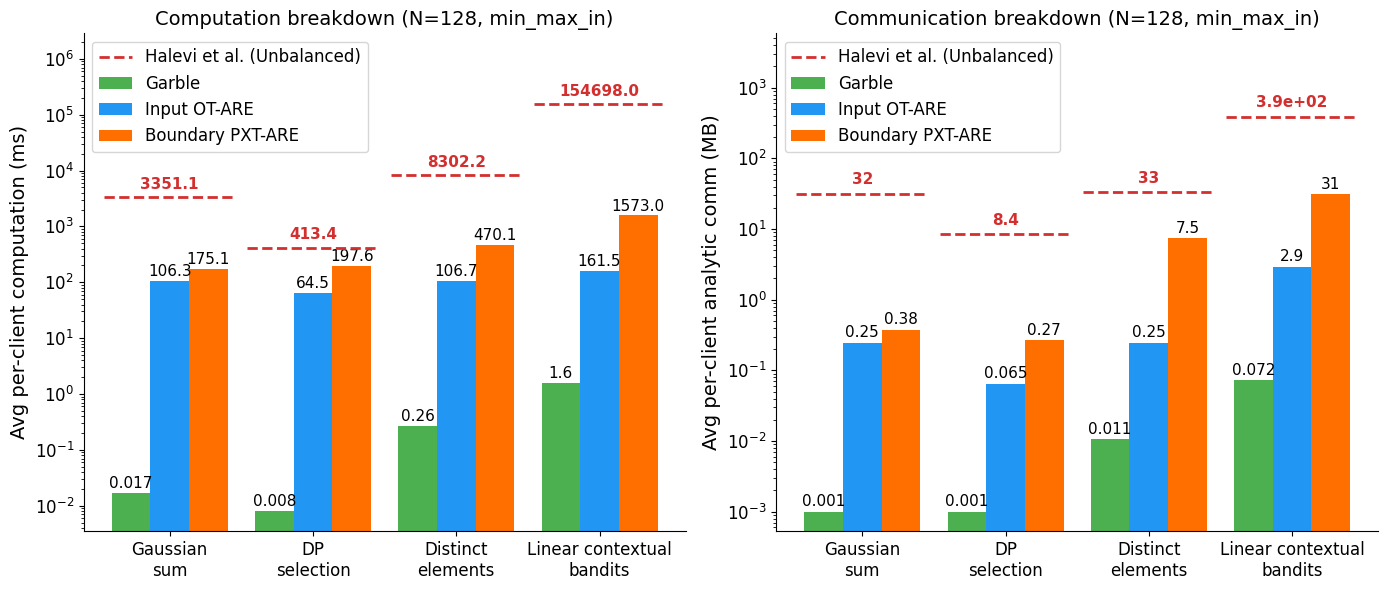

                   circuit  t_garble    t_input       t_bnd  b_garble  b_input     b_bnd
             Gaussian\nsum  0.017202 106.338898  175.119087  0.001000 0.245760  0.377832
             DP\nselection  0.008005  64.544282  197.636118  0.001000 0.065068  0.267530
        Distinct\nelements  0.263654 106.739504  470.104852  0.010620 0.247453  7.455526
Linear contextual\nbandits  1.591068 161.531583 1572.962614  0.072178 2.949120 31.068805

Unbalanced client-0 baselines at N= 128
   t_total    b_total
  3351.130  31.525920
   413.386   8.380864
  8302.240  33.062560
154698.000 386.731200


In [4]:
# ── Average-case breakdown: balanced bars + unbalanced reference line ────────
PAPER_N    = 128
PAPER_MODE = 'min_max_in'
LOG_FLOOR  = 1e-3

AXIS_FS, TITLE_FS, LEGEND_FS, TICK_FS, ANNOT_FS = 14, 14, 12, 12, 11

PANEL_CIRCUITS = ['gausssum', 'select', 'distinct', 'lcb']
PANEL_TITLES = {
    'gausssum': 'Gaussian\nsum',
    'select':   'DP\nselection',
    'distinct': 'Distinct\nelements',
    'lcb':      'Linear contextual\nbandits',
}

rows, unbal_rows = [], []
for circ in PANEL_CIRCUITS:
    sub = df[(df['experiment'] == f'net_{circ}_N{PAPER_N}_{PAPER_MODE}')
             & (df['client_id'] > 0)]
    ub  = df[(df['experiment'] == f'net_{circ}_N{PAPER_N}_unbal')
             & (df['client_id'] == 0)]
    if len(sub) == 0:
        continue
    rows.append({
        'circuit':  PANEL_TITLES[circ],
        't_garble': max(sub['garble_time_us'].mean()   / 1000.0, LOG_FLOOR),
        't_input':  max(sub['ot_are_time_us'].mean()   / 1000.0, LOG_FLOOR),
        't_bnd':    max(sub['boundary_time_us'].mean() / 1000.0, LOG_FLOOR),
        'b_garble': max(sub['garbled_table_bytes'].mean() / 1e6, LOG_FLOOR),
        'b_input':  max(sub['ot_are_bytes'].mean()        / 1e6, LOG_FLOOR),
        'b_bnd':    max(sub['boundary_bytes'].mean()      / 1e6, LOG_FLOOR),
    })
    if len(ub) > 0:
        unbal_rows.append({
            't_total': ub['total_time_us'].iloc[0] / 1000.0,
            'b_total': ub['total_bytes'].iloc[0]   / 1e6,
        })
    else:
        unbal_rows.append({'t_total': np.nan, 'b_total': np.nan})
breakdown = pd.DataFrame(rows)
unbal_df  = pd.DataFrame(unbal_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
n_circ   = len(breakdown)
x        = np.arange(n_circ)
bar_w    = 0.27
labels   = breakdown['circuit'].values
colors   = {'garble': '#4CAF50', 'input': '#2196F3', 'bnd': '#FF6F00'}
disp     = {'garble': 'Garble', 'input': 'Input OT-ARE', 'bnd': 'Boundary PXT-ARE'}
UNBAL_C  = '#D32F2F'

def plot_grouped(ax, vals_g, vals_i, vals_b, unbal_vals, ylabel, value_fmt, title):
    rects_g = ax.bar(x - bar_w, vals_g, bar_w, color=colors['garble'], label=disp['garble'])
    rects_i = ax.bar(x,         vals_i, bar_w, color=colors['input'],  label=disp['input'])
    rects_b = ax.bar(x + bar_w, vals_b, bar_w, color=colors['bnd'],    label=disp['bnd'])
    for rects, vals in [(rects_g, vals_g), (rects_i, vals_i), (rects_b, vals_b)]:
        for r, v in zip(rects, vals):
            ax.text(r.get_x() + r.get_width()/2, v * 1.08, value_fmt(v),
                    ha='center', va='bottom', fontsize=ANNOT_FS, rotation=0)
    for xi, ub_v in enumerate(unbal_vals):
        if np.isnan(ub_v):
            continue
        lbl = 'Halevi et al. (Unbalanced)' if xi == 0 else None
        ax.hlines(ub_v, xi - bar_w*1.7, xi + bar_w*1.7,
                  color=UNBAL_C, linewidth=2.0, linestyle='--',
                  label=lbl, zorder=5)
        ax.text(xi, ub_v * 1.25, value_fmt(ub_v),
                color=UNBAL_C, fontsize=ANNOT_FS, ha='center', va='bottom',
                fontweight='bold')
    ax.set_yscale('log')
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 8)
    ax.set_xlim(-0.6, n_circ - 0.4)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=0, ha='center')
    ax.set_ylabel(ylabel, fontsize=AXIS_FS)
    ax.set_title(title, fontsize=TITLE_FS)
    ax.legend(fontsize=LEGEND_FS, loc='upper left')
    ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

plot_grouped(
    axes[0],
    breakdown['t_garble'].values,
    breakdown['t_input'].values,
    breakdown['t_bnd'].values,
    unbal_df['t_total'].values,
    'Avg per-client computation (ms)',
    lambda v: f'{v:.1f}' if v >= 1 else f'{v:.2g}',
    f'Computation breakdown (N={PAPER_N}, {PAPER_MODE})',
)
plot_grouped(
    axes[1],
    breakdown['b_garble'].values,
    breakdown['b_input'].values,
    breakdown['b_bnd'].values,
    unbal_df['b_total'].values,
    'Avg per-client analytic comm (MB)',
    lambda v: f'{v:.2g}',
    f'Communication breakdown (N={PAPER_N}, {PAPER_MODE})',
)

plt.tight_layout()
plt.savefig('benchmark/avg-breakdown.png', dpi=130, bbox_inches='tight')
plt.show()

print(breakdown.to_string(index=False))
print('\nUnbalanced client-0 baselines at N=', PAPER_N)
print(unbal_df.to_string(index=False))


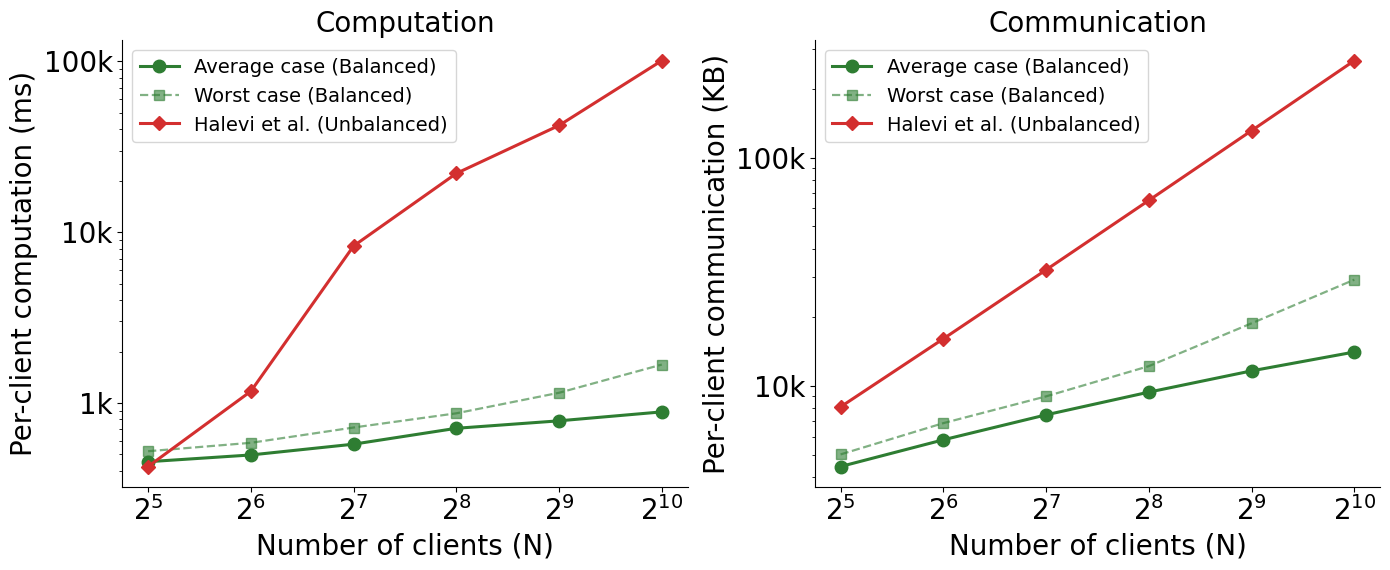

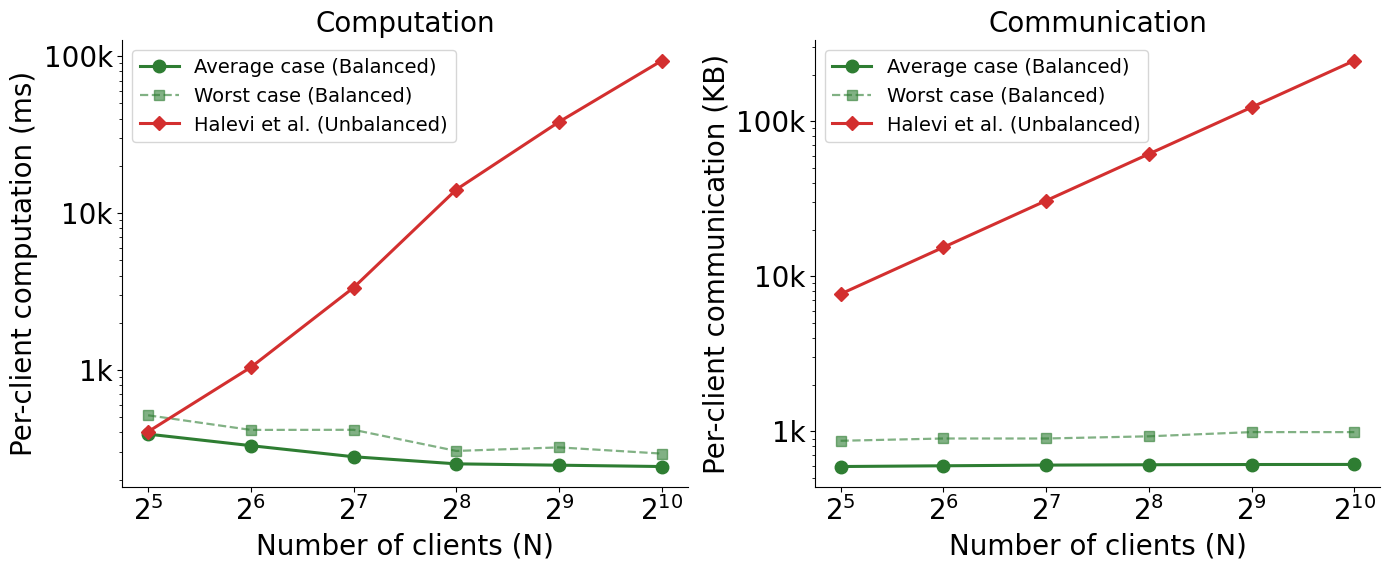

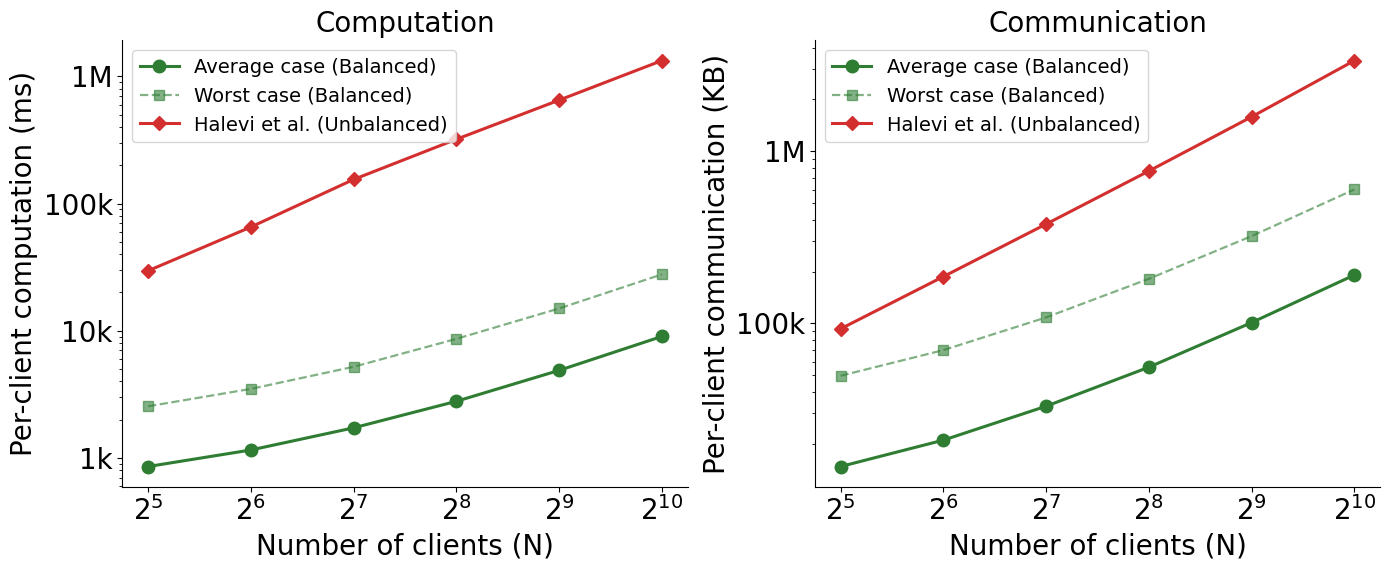

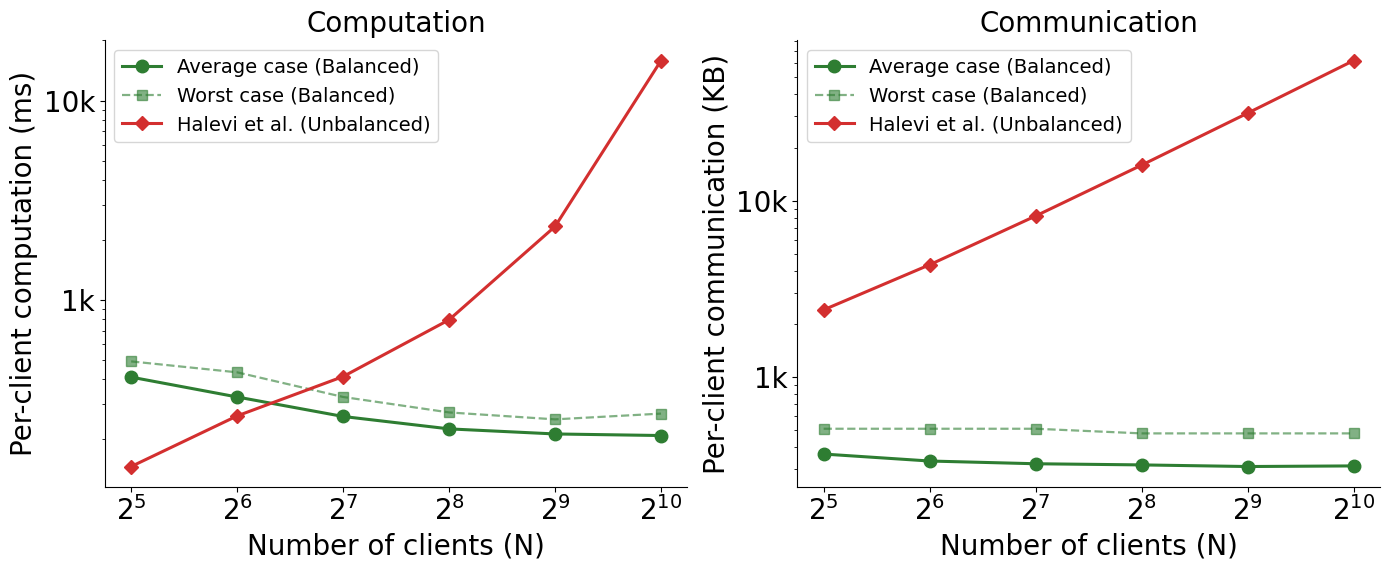

In [5]:
# ── Per-circuit scaling line plots: min_max_in vs unbalanced (paper figure) ──
from matplotlib.ticker import FuncFormatter

# Re-declared here so this cell stands on its own (downstream cells rely on
# these dicts existing in scope).
MODE_LABELS = {
    'topo_bal':   'Topological Balanced',
    'nonxor_bal': 'Non-XOR Balanced',
    'min_cut':    'Min-Cut Balanced',
    'min_max_in': 'Min-Max boundary',
}
MODE_COLORS = {
    'topo_bal':   '#2196F3',
    'nonxor_bal': '#4CAF50',
    'min_cut':    '#9C27B0',
    'min_max_in': '#FF6F00',
}

PLOT_MODE  = 'min_max_in'
mode_label = MODE_LABELS[PLOT_MODE]
BAL_COLOR  = '#2E7D32'   # green for the balanced strategy
UNBAL_C    = '#D32F2F'

AXIS_FS, TITLE_FS, SUPTITLE_FS, LEGEND_FS, TICK_FS = 20, 20, 18, 14, 20

def fmt_y(v, _):
    if v <= 0:    return ''
    if v >= 1e9:  return f'{v/1e9:g}G'
    if v >= 1e6:  return f'{v/1e6:g}M'
    if v >= 1e3:  return f'{v/1e3:g}k'
    if v >= 1:    return f'{v:.0f}'
    return f'{v:g}'

def fmt_x_pow2(v, _):
    return f'$2^{{{int(round(np.log2(v)))}}}$'

circuit_types = sorted(bal_runs['circuit_type'].unique())

for ct in circuit_types:
    sub = bal_runs[(bal_runs['circuit_type'] == ct) & (bal_runs['mode'] == PLOT_MODE)].sort_values('n_clients')
    if len(sub) == 0:
        continue
    x = sub['n_clients'].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

    # --- Computation ---
    axes[0].plot(x, sub['avg_comp_ms'],   'o-',  color=BAL_COLOR, linewidth=2.2, markersize=9, label=f'Average case (Balanced)')
    axes[0].plot(x, sub['max_comp_ms'],   's--', color=BAL_COLOR, linewidth=1.6, markersize=7, alpha=0.6, label=f'Worst case (Balanced)')
    axes[0].plot(x, sub['unbal_comp_ms'], 'D-',  color=UNBAL_C,   linewidth=2.2, markersize=7, label='Halevi et al. (Unbalanced)')
    axes[0].set_xscale('log', base=2)
    axes[0].set_yscale('log')
    axes[0].set_xticks(x)
    axes[0].xaxis.set_major_formatter(FuncFormatter(fmt_x_pow2))
    axes[0].yaxis.set_major_formatter(FuncFormatter(fmt_y))
    axes[0].set_xlabel('Number of clients (N)',     fontsize=AXIS_FS)
    axes[0].set_ylabel('Per-client computation (ms)', fontsize=AXIS_FS)
    axes[0].set_title('Computation', fontsize=TITLE_FS)
    axes[0].legend(fontsize=LEGEND_FS, loc='best')
    axes[0].tick_params(axis='both', which='major', labelsize=TICK_FS)
    for spine in ('top', 'right'):
        axes[0].spines[spine].set_visible(False)

    # --- Communication ---
    axes[1].plot(x, sub['avg_comm_KB'],   'o-',  color=BAL_COLOR, linewidth=2.2, markersize=9, label=f'Average case (Balanced)')
    axes[1].plot(x, sub['max_comm_KB'],   's--', color=BAL_COLOR, linewidth=1.6, markersize=7, alpha=0.6, label=f'Worst case (Balanced)')
    axes[1].plot(x, sub['unbal_comm_KB'], 'D-',  color=UNBAL_C,   linewidth=2.2, markersize=7, label='Halevi et al. (Unbalanced)')
    axes[1].set_xscale('log', base=2)
    axes[1].set_yscale('log')
    axes[1].set_xticks(x)
    axes[1].xaxis.set_major_formatter(FuncFormatter(fmt_x_pow2))
    axes[1].yaxis.set_major_formatter(FuncFormatter(fmt_y))
    axes[1].set_xlabel('Number of clients (N)',       fontsize=AXIS_FS)
    axes[1].set_ylabel('Per-client communication (KB)', fontsize=AXIS_FS)
    axes[1].set_title('Communication', fontsize=TITLE_FS)
    axes[1].legend(fontsize=LEGEND_FS, loc='best')
    axes[1].tick_params(axis='both', which='major', labelsize=TICK_FS)
    for spine in ('top', 'right'):
        axes[1].spines[spine].set_visible(False)

    plt.tight_layout()
    safe_ct = ct.lower().replace(' ', '-')
    plt.savefig(f'benchmark/scaling-{safe_ct}-{PLOT_MODE}.png', dpi=130, bbox_inches='tight')
    plt.show()


In [61]:
# ── Summary tables: one per (circuit, balancing mode) ──────────────────────────

cols = ['n_clients', 'circuit', 'mode', 'circuit_gates', 'total_and', 'total_inputs',
        'total_boundary', 'avg_comp_ms', 'max_comp_ms', 'unbal_comp_ms', 'comp_speedup',
        'avg_comm_KB', 'max_comm_KB', 'unbal_comm_KB', 'comm_speedup']

for ct in sorted(bal_runs['circuit_type'].unique()):
    for mode in BAL_MODES:
        sub = bal_runs[(bal_runs['circuit_type'] == ct) & (bal_runs['mode'] == mode)].sort_values('n_clients')
        if len(sub) == 0:
            continue
        print(f'=== {ct} — {MODE_LABELS[mode]} ===')
        display_cols = [c for c in cols if c in sub.columns]
        display_df = sub[display_cols].copy()
        for c in display_df.columns:
            if display_df[c].dtype == float:
                display_df[c] = display_df[c].round(1)
        display(display_df)
        print()


=== Distinct Elements — Topological Balanced ===


,n_clients,circuit,mode,circuit_gates,total_and,total_inputs,total_boundary,avg_comp_ms,max_comp_ms,unbal_comp_ms,comp_speedup,avg_comm_KB,max_comm_KB,unbal_comm_KB,comm_speedup
18,32,distinct,topo_bal,17687,5831,264,4468,468.1,530.5,424.3,0.9,4441.9,5164.2,8102.2,1.8
26,64,distinct,topo_bal,48645,16086,520,11866,516.8,605.1,1170.4,2.3,5813.8,6965.7,16102.7,2.8
6,128,distinct,topo_bal,128227,42485,1032,30822,590.3,720.2,8302.2,14.1,7476.2,9007.5,32287.7,4.3
14,256,distinct,topo_bal,327137,108532,2056,78047,711.7,869.2,22089.5,31.0,9400.3,13753.2,65071.6,6.9
22,512,distinct,topo_bal,813279,270067,4104,193477,774.9,1275.7,42180.2,54.4,11593.5,22455.2,131559.6,11.3
2,1024,distinct,topo_bal,1979869,657906,8200,469453,861.1,1951.4,101064.0,117.4,14013.8,35424.9,266559.6,19.0



=== Distinct Elements — Non-XOR Balanced ===


,n_clients,circuit,mode,circuit_gates,total_and,total_inputs,total_boundary,avg_comp_ms,max_comp_ms,unbal_comp_ms,comp_speedup,avg_comm_KB,max_comm_KB,unbal_comm_KB,comm_speedup
17,32,distinct,nonxor_bal,17687,5831,264,4350,453.7,589.7,424.3,0.9,4331.3,6545.7,8102.2,1.9
25,64,distinct,nonxor_bal,48645,16086,520,11864,496.7,722.0,1170.4,2.4,5812.9,9367.9,16102.7,2.8
5,128,distinct,nonxor_bal,128227,42485,1032,31020,579.9,860.2,8302.2,14.3,7522.6,12850.4,32287.7,4.3
13,256,distinct,nonxor_bal,327137,108532,2056,78463,714.5,1005.3,22089.5,30.9,9449.1,15283.2,65071.6,6.9
21,512,distinct,nonxor_bal,813279,270067,4104,194122,779.7,1147.6,42180.2,54.1,11631.3,18856.5,131559.6,11.3
1,1024,distinct,nonxor_bal,1979869,657906,8200,471444,862.6,1968.6,101064.0,117.2,14072.1,35300.1,266559.6,18.9



=== Distinct Elements — Min-Max boundary ===


...

,n_clients,circuit,mode,circuit_gates,total_and,total_inputs,total_boundary,avg_comp_ms,max_comp_ms,unbal_comp_ms,comp_speedup,avg_comm_KB,max_comm_KB,unbal_comm_KB,comm_speedup
114,32,select,topo_bal,484,208,80,313,416.6,513.9,146.4,0.4,368.6,540.2,2406.5,6.5
122,64,select,topo_bal,929,399,144,590,325.8,424.3,262.5,0.8,344.3,540.2,4332.5,12.6
102,128,select,topo_bal,1822,782,272,1107,262.5,335.3,413.4,1.6,323.4,510.2,8184.4,25.3
110,256,select,topo_bal,3611,1549,528,2155,231.9,275.1,795.9,3.4,314.6,510.2,15888.4,50.5
118,512,select,topo_bal,7192,3084,1040,4434,216.6,262.8,2336.4,10.8,320.9,510.2,31296.4,97.5
98,1024,select,topo_bal,14357,6155,2064,8979,211.7,251.7,15844.4,74.9,323.7,510.2,62112.3,191.9



=== Selection — Non-XOR Balanced ===


,n_clients,circuit,mode,circuit_gates,total_and,total_inputs,total_boundary,avg_comp_ms,max_comp_ms,unbal_comp_ms,comp_speedup,avg_comm_KB,max_comm_KB,unbal_comm_KB,comm_speedup
113,32,select,nonxor_bal,484,208,80,311,419.1,542.6,146.4,0.3,366.8,540.2,2406.5,6.6
121,64,select,nonxor_bal,929,399,144,570,319.2,425.0,262.5,0.8,334.9,540.2,4332.5,12.9
101,128,select,nonxor_bal,1822,782,272,1102,261.8,353.4,413.4,1.6,322.2,540.2,8184.4,25.4
109,256,select,nonxor_bal,3611,1549,528,2179,226.2,285.1,795.9,3.5,317.4,480.2,15888.4,50.1
117,512,select,nonxor_bal,7192,3084,1040,4250,213.6,250.9,2336.4,10.9,310.1,480.2,31296.4,100.9
97,1024,select,nonxor_bal,14357,6155,2064,8615,207.8,238.9,15844.4,76.2,313.0,480.2,62112.3,198.4



=== Selection — Min-Max boundary ===


,n_clients,circuit,mode,circuit_gates,total_and,total_inputs,total_boundary,avg_comp_ms,max_comp_ms,unbal_comp_ms,comp_speedup,avg_comm_KB,max_comm_KB,unbal_comm_KB,comm_speedup
112,32,select,min_max_in,484,208,80,311,410.7,492.4,146.4,0.4,366.8,510.2,2406.5,6.6
120,64,select,min_max_in,929,399,144,570,326.6,434.1,262.5,0.8,334.9,510.2,4332.5,12.9
100,128,select,min_max_in,1822,782,272,1106,260.8,326.7,413.4,1.6,323.2,510.2,8184.4,25.3
108,256,select,min_max_in,3611,1549,528,2187,226.0,273.3,795.9,3.5,318.4,480.2,15888.4,49.9
116,512,select,min_max_in,7192,3084,1040,4276,213.1,252.3,2336.4,11.0,311.7,480.2,31296.4,100.4
96,1024,select,min_max_in,14357,6155,2064,8654,209.3,269.6,15844.4,75.7,314.2,480.2,62112.3,197.7


In [62]:
# ── Verify Table tab:speedup-1024 in exp.tex ──────────────────────────────────
# Formula: speedup = cost_unbal_client0 / mean(cost_balanced) at N=1024.
verify_rows = []
for circ in ['gausssum', 'select', 'distinct', 'lcb']:
    bal = df[df['experiment'] == f'net_{circ}_N1024_min_max_in']
    unb = df[(df['experiment'] == f'net_{circ}_N1024_unbal') & (df['client_id'] == 0)]
    if len(bal) == 0 or len(unb) == 0:
        continue
    u_ms = unb['total_time_us'].iloc[0] / 1e3
    b_ms = bal['total_time_us'].mean()  / 1e3
    u_mb = unb['total_bytes'].iloc[0]   / 1e6
    b_mb = bal['total_bytes'].mean()    / 1e6
    verify_rows.append({
        'circuit':       circ,
        'unbal_c0_ms':   round(u_ms, 1),
        'bal_avg_ms':    round(b_ms, 1),
        'comp_speedup':  round(u_ms / b_ms, 1),
        'unbal_c0_MB':   round(u_mb, 1),
        'bal_avg_MB':    round(b_mb, 1),
        'comm_speedup':  round(u_mb / b_mb, 1),
    })
verify_df = pd.DataFrame(verify_rows)
print('Speedup verification at N=1024 (analytic communication):\n')
print(verify_df.to_string(index=False))


Speedup verification at N=1024 (analytic communication):

 circuit  unbal_c0_ms  bal_avg_ms  comp_speedup  unbal_c0_MB  bal_avg_MB  comm_speedup
gausssum      93711.0       242.7         386.2        252.2         0.6         402.0
  select      15844.4       209.3          75.7         63.6         0.3         197.7
distinct     101064.0       886.4         114.0        273.0        14.4          18.9
     lcb    1330180.0      9017.0         147.5       3444.0       195.7          17.6
